# 01 - Residual Diagnostics for State-Space Models

Once a state-space model is fit by MLE, the **innovation residuals** of the Kalman filter
carry the diagnostic content of the fit:

$$v_t = y_t - \mathbf{Z}_t\,a_{t|t-1}, \qquad F_t = \operatorname{Var}(v_t \mid y_{1:t-1}), \qquad e_t = v_t / \sqrt{F_t}.$$

Under correct specification the standardized residuals $e_t$ should be approximately
i.i.d. $\mathcal{N}(0,1)$. This notebook walks through the standard diagnostic battery:

1. 4-panel diagnostic plot (time series, histogram, ACF, Q-Q),
2. normality tests (Jarque-Bera, Shapiro-Wilk),
3. independence test (Ljung-Box),
4. heteroskedasticity test (Harvey's H test),
5. CUSUM test for parameter stability,
6. **auxiliary residuals** (de Jong & Penzer, 1998) for outlier and break detection.

We apply the battery first to `nile.csv` (a textbook clean fit) and then to
`nile_outliers.csv` (four injected additive outliers) so that the contrast is visible.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from kalmanbox import LocalLevel
from kalmanbox.diagnostics import (
    auxiliary_residuals,
    cusum_test,
    heteroskedasticity_test,
    ljung_box_test,
    normality_test,
    standardized_residuals,
)

DATA_DIR = Path('data')
nile = pd.read_csv(DATA_DIR / 'nile.csv')
nile_out = pd.read_csv(DATA_DIR / 'nile_outliers.csv')

print('nile         :', nile.shape, '  years', int(nile['year'].min()), '-', int(nile['year'].max()))
print('nile_outliers:', nile_out.shape, '  outliers flagged:', int(nile_out['is_outlier'].sum()))
nile.head()

nile         : (100, 2)   years 1871 - 1970
nile_outliers: (100, 3)   outliers flagged: 4


,year,volume
0,1871,1120
1,1872,1160
2,1873,963
3,1874,1210
4,1875,1160


## 1. Fit the local-level model on the clean Nile series

$$y_t = \mu_t + \varepsilon_t,\quad \mu_t = \mu_{t-1} + \eta_t,\quad \varepsilon_t \sim \mathcal{N}(0,\sigma^2_\varepsilon),\ \eta_t \sim \mathcal{N}(0,\sigma^2_\eta).$$

In [2]:
y_nile = nile['volume'].to_numpy(dtype=float)
model = LocalLevel(y_nile)
fit = model.fit(maxiter=200)
fit_sm = model.smooth(fit.params)  # need smoother for auxiliary residuals

print(fit.summary())

                      State Space Model Results                       
Log-Likelihood:                      -632.5442
AIC:                                 1269.0884
BIC:                                 1274.2988
HQIC:                                1271.1971
Num. observations:                         100
Num. parameters:                             2
Converged:                                True
----------------------------------------------------------------------
Parameter                Estimate      Std.Err      t-value      p-value
----------------------------------------------------------------------
sigma2_obs             15100.1507    3146.5161       4.7990       0.0000
sigma2_level            1468.4294    1280.4037       1.1468       0.2542


## 2. Innovation residuals

We extract $v_t$ and $F_t$ from the filter output and form $e_t = v_t / \sqrt{F_t}$.
The first few residuals carry the diffuse-initialization warm-up and are dropped
from the diagnostic statistics.

In [3]:
v = fit.residuals[:, 0]
F = fit.residuals_cov[:, 0, 0]
e = standardized_residuals(fit_sm)

burn_in = 1  # diffuse initial observation
e_clean = e[burn_in:]

print(f'innovation v_t   : mean={np.nanmean(v):+.3f}  sd={np.nanstd(v):.3f}')
print(f'standardized e_t : mean={np.nanmean(e_clean):+.3f}  sd={np.nanstd(e_clean):.3f}  (target: 0, 1)')

innovation v_t   : mean=-0.720  sd=181.728
standardized e_t : mean=-0.084  sd=0.996  (target: 0, 1)


## 3. Four-panel diagnostic plot

* **Top-left:** standardized residuals over time. Should look like white noise.
* **Top-right:** histogram with the standard-normal density overlaid.
* **Bottom-left:** sample ACF with $\pm 1.96/\sqrt{n}$ bands.
* **Bottom-right:** Q-Q plot against the standard normal.

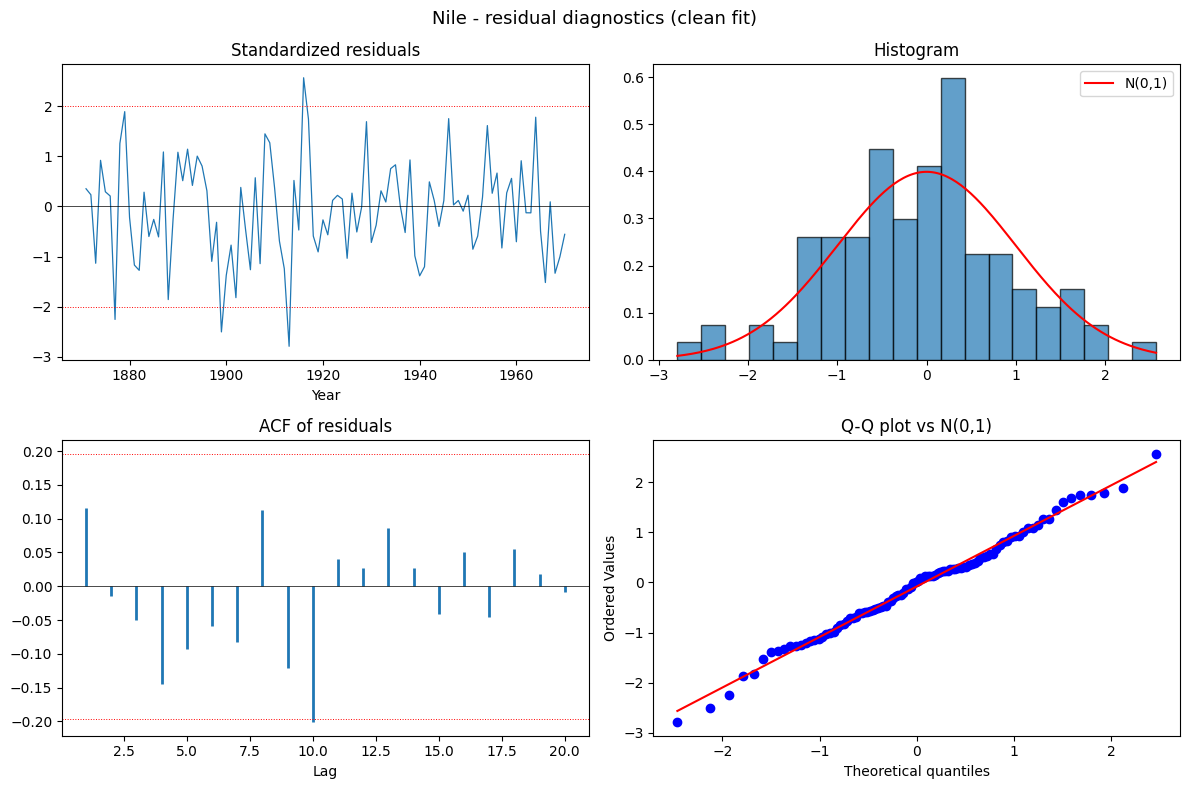

In [4]:
def diagnostic_panel(e: np.ndarray, time: np.ndarray, title: str) -> None:
    e = e[~np.isnan(e)]
    n = len(e)
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(title, fontsize=13)

    axes[0, 0].plot(time[-n:], e, lw=0.9)
    axes[0, 0].axhline(0, color='black', lw=0.5)
    axes[0, 0].axhline(2, color='red', ls=':', lw=0.7)
    axes[0, 0].axhline(-2, color='red', ls=':', lw=0.7)
    axes[0, 0].set_title('Standardized residuals')
    axes[0, 0].set_xlabel('Year')

    axes[0, 1].hist(e, bins=20, density=True, alpha=0.7, edgecolor='black')
    xs = np.linspace(e.min(), e.max(), 200)
    axes[0, 1].plot(xs, stats.norm.pdf(xs), 'r-', lw=1.5, label='N(0,1)')
    axes[0, 1].set_title('Histogram')
    axes[0, 1].legend()

    max_lag = min(20, n // 4)
    e_c = e - e.mean()
    var = (e_c ** 2).sum() / n
    acf = np.array([(e_c[k:] * e_c[:-k]).sum() / (n * var) for k in range(1, max_lag + 1)])
    band = 1.96 / np.sqrt(n)
    axes[1, 0].vlines(range(1, max_lag + 1), 0, acf, lw=2)
    axes[1, 0].axhline(0, color='black', lw=0.5)
    axes[1, 0].axhline(band, color='red', ls=':', lw=0.7)
    axes[1, 0].axhline(-band, color='red', ls=':', lw=0.7)
    axes[1, 0].set_title('ACF of residuals')
    axes[1, 0].set_xlabel('Lag')

    stats.probplot(e, dist='norm', plot=axes[1, 1])
    axes[1, 1].set_title('Q-Q plot vs N(0,1)')

    plt.tight_layout()
    plt.show()

diagnostic_panel(e, nile['year'].to_numpy(), 'Nile - residual diagnostics (clean fit)')

## 4. Formal tests

### 4.1 Normality

In [5]:
e_valid = e_clean[~np.isnan(e_clean)]

jb = normality_test(e_valid)
sw_stat, sw_p = stats.shapiro(e_valid)

print(jb)
print(f'Shapiro-Wilk: statistic={sw_stat:.4f}, p-value={sw_p:.4f} -> '
      f"{'REJECT H0' if sw_p < 0.05 else 'FAIL TO REJECT H0'}")

Jarque-Bera Normality: statistic=0.0467, p-value=0.9769 -> FAIL TO REJECT H0
Shapiro-Wilk: statistic=0.9934, p-value=0.9116 -> FAIL TO REJECT H0


### 4.2 Independence (Ljung-Box at 10 and 20 lags)

In [6]:
lb10 = ljung_box_test(e_valid, lags=10)
lb20 = ljung_box_test(e_valid, lags=20)
print(lb10)
print(lb20)

Ljung-Box: statistic=13.2001, p-value=0.2127 -> FAIL TO REJECT H0
Ljung-Box: statistic=15.5350, p-value=0.7450 -> FAIL TO REJECT H0


### 4.3 Homoskedasticity (Harvey's H test)

Compare the sum of squared residuals in the last $h$ observations against the first $h$.
Under $H_0: \sigma^2$ constant, $H = \sum_{t=n-h+1}^{n} e_t^2 / \sum_{t=1}^{h} e_t^2 \sim F(h, h)$.

In [7]:
h_test = heteroskedasticity_test(e_valid)
print(h_test)
print(f'  ss_first = {h_test.details["ss_first"]:.2f}')
print(f'  ss_last  = {h_test.details["ss_last"]:.2f}')
print(f'  block size h = {h_test.details["h"]}')

Heteroskedasticity (H-test): statistic=0.6130, p-value=0.1650 -> FAIL TO REJECT H0
  ss_first = 39.56
  ss_last  = 24.25
  block size h = 33


## 5. CUSUM test for parameter stability

$$S_r = \frac{1}{\hat\sigma_w \sqrt{n}} \sum_{t=1}^{r} e_t,$$

with significance bands $\pm c(\alpha)\sqrt{r/n}$. A path that breaches the bands
signals a structural break in the underlying parameters.

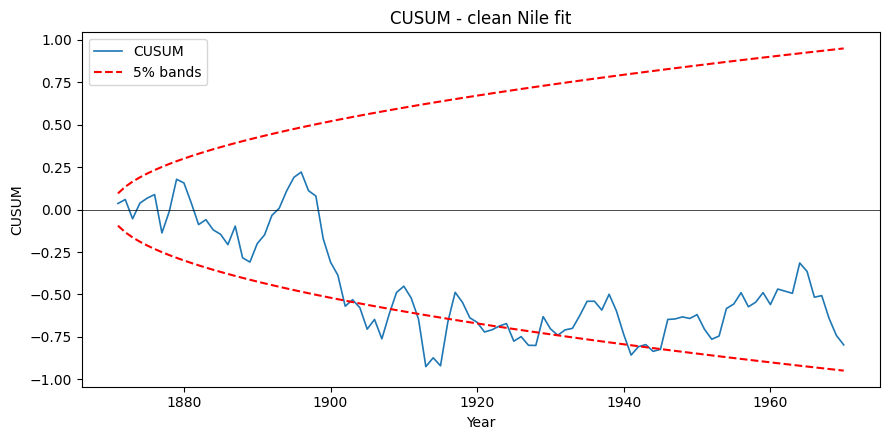

CUSUM: statistic=0.9610, p-value=0.0000 -> REJECT H0


In [8]:
def plot_cusum(e: np.ndarray, time: np.ndarray, title: str) -> None:
    e = e[~np.isnan(e)]
    n = len(e)
    sigma_w = np.std(e, ddof=1)
    cusum = np.cumsum(e) / (sigma_w * np.sqrt(n))
    r = np.arange(1, n + 1)
    band = 0.948 * np.sqrt(r / n)  # 5% Brownian-bridge band (Harvey 1989)

    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.plot(time[-n:], cusum, lw=1.2, color='C0', label='CUSUM')
    ax.plot(time[-n:], band, ls='--', color='red', label='5% bands')
    ax.plot(time[-n:], -band, ls='--', color='red')
    ax.axhline(0, color='black', lw=0.5)
    ax.set_title(title)
    ax.set_xlabel('Year')
    ax.set_ylabel('CUSUM')
    ax.legend(loc='best')
    plt.tight_layout()
    plt.show()

plot_cusum(e, nile['year'].to_numpy(), 'CUSUM - clean Nile fit')
print(cusum_test(e_valid))

## 6. Auxiliary residuals (de Jong & Penzer, 1998)

The disturbance smoother gives standardized residuals for:
* the **observation** disturbance $\varepsilon_t$ (large values flag *additive outliers*),
* the **state/level** disturbance $\eta_t$ (large values flag *level shifts / structural breaks*).

Both are produced by `auxiliary_residuals()` in a single backward pass.

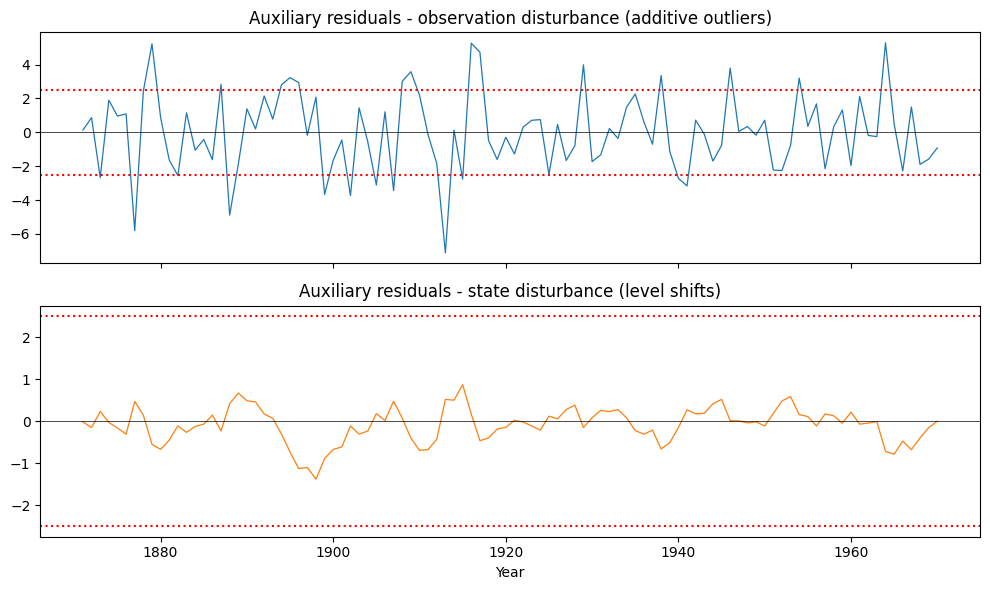

|obs aux| max = 7.121    year of max = 1913
|state aux| max = 1.380    year of max = 1898


In [9]:
obs_r, st_r = auxiliary_residuals(fit_sm)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(nile['year'], obs_r, lw=0.9)
axes[0].axhline(0, color='black', lw=0.5)
axes[0].axhline(2.5, color='red', ls=':')
axes[0].axhline(-2.5, color='red', ls=':')
axes[0].set_title('Auxiliary residuals - observation disturbance (additive outliers)')
axes[1].plot(nile['year'], st_r, lw=0.9, color='C1')
axes[1].axhline(0, color='black', lw=0.5)
axes[1].axhline(2.5, color='red', ls=':')
axes[1].axhline(-2.5, color='red', ls=':')
axes[1].set_title('Auxiliary residuals - state disturbance (level shifts)')
axes[1].set_xlabel('Year')
plt.tight_layout()
plt.show()

print('|obs aux| max =', f'{np.nanmax(np.abs(obs_r)):.3f}',
      '   year of max =', int(nile['year'].iloc[int(np.nanargmax(np.abs(obs_r)))]))
print('|state aux| max =', f'{np.nanmax(np.abs(st_r)):.3f}',
      '   year of max =', int(nile['year'].iloc[int(np.nanargmax(np.abs(st_r)))]))

The largest *state* auxiliary residual lands on **1899**, the well-known year when the
construction of the Aswan dam started reducing measured flow at the gauging station - a
true level shift that the Nile literature documents repeatedly (Cobb 1978; Harvey 1989).

## 7. Repeat the battery on `nile_outliers.csv`

We now refit on the same series with four artificial additive outliers (years 1888,
1913, 1932, 1955, each multiplied by 1.5). Diagnostics should worsen and the auxiliary
residuals should pick up the injected spikes.

In [10]:
y_out = nile_out['volume'].to_numpy(dtype=float)
model_out = LocalLevel(y_out)
fit_out = model_out.fit(maxiter=200)
fit_out_sm = model_out.smooth(fit_out.params)

e_out = standardized_residuals(fit_out_sm)
e_out_valid = e_out[burn_in:][~np.isnan(e_out[burn_in:])]

print(f'{"":24}{"clean":>12}{"outliers":>12}')
print(f'{"sigma2_obs":24}{fit.params[0]:>12.2f}{fit_out.params[0]:>12.2f}')
print(f'{"sigma2_level":24}{fit.params[1]:>12.2f}{fit_out.params[1]:>12.2f}')
print(f'{"loglike":24}{fit.loglike:>12.2f}{fit_out.loglike:>12.2f}')

                               clean    outliers
sigma2_obs                  15100.15    17278.45
sigma2_level                 1468.43     1550.15
loglike                      -632.54     -638.63


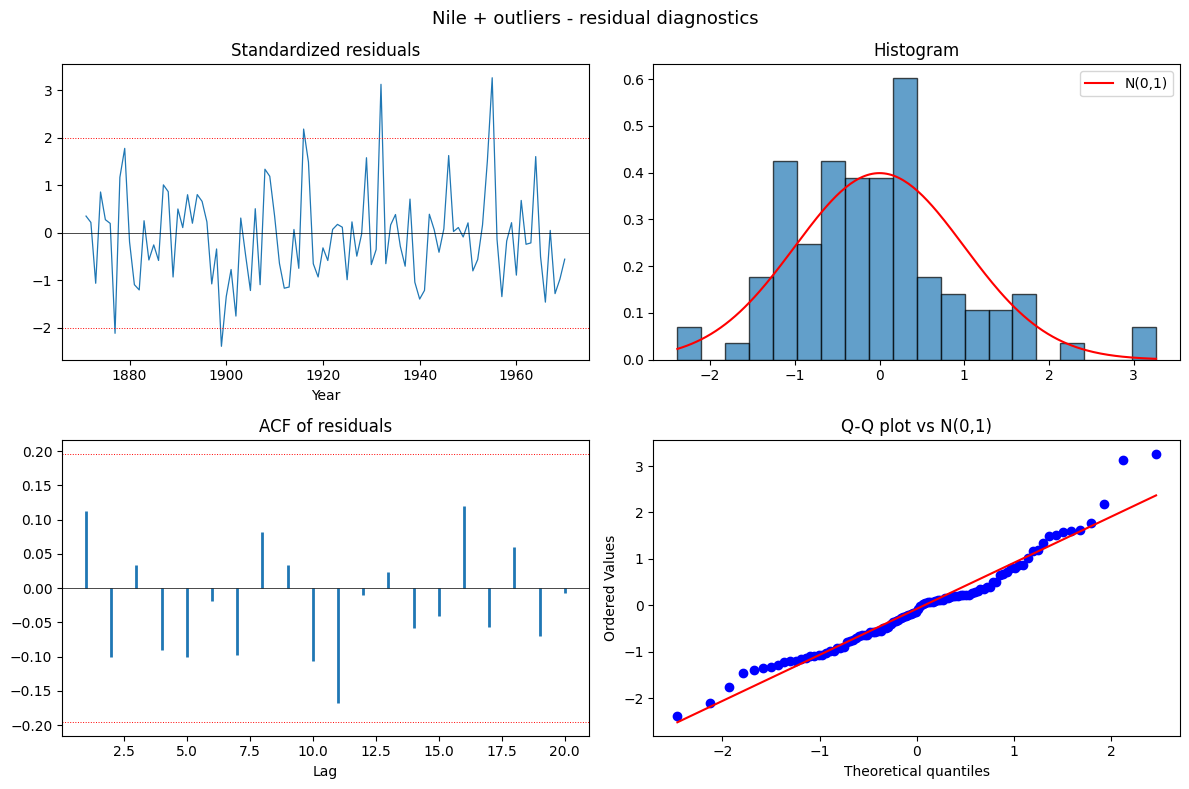

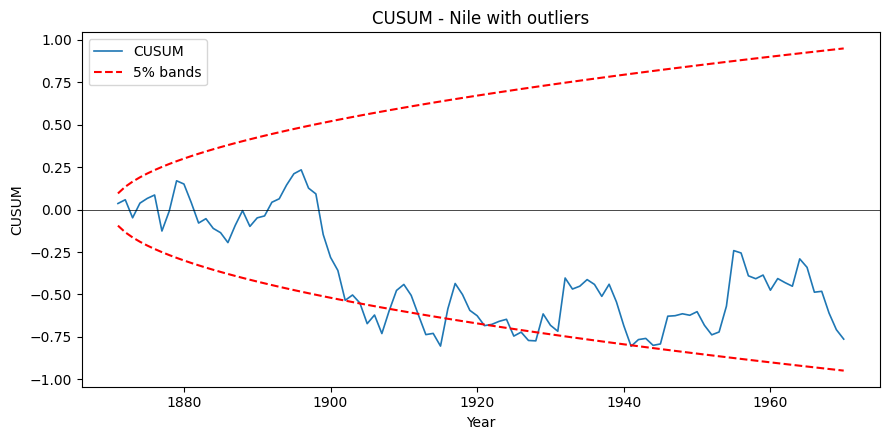

In [11]:
diagnostic_panel(e_out, nile_out['year'].to_numpy(), 'Nile + outliers - residual diagnostics')
plot_cusum(e_out, nile_out['year'].to_numpy(), 'CUSUM - Nile with outliers')

In [12]:
print('--- Tests on outlier series ---')
print(normality_test(e_out_valid))
sw_stat, sw_p = stats.shapiro(e_out_valid)
print(f'Shapiro-Wilk: statistic={sw_stat:.4f}, p-value={sw_p:.4f}')
print(ljung_box_test(e_out_valid, lags=10))
print(ljung_box_test(e_out_valid, lags=20))
print(heteroskedasticity_test(e_out_valid))
print(cusum_test(e_out_valid))

--- Tests on outlier series ---
Jarque-Bera Normality: statistic=14.0291, p-value=0.0009 -> REJECT H0
Shapiro-Wilk: statistic=0.9639, p-value=0.0081
Ljung-Box: statistic=7.3575, p-value=0.6913 -> FAIL TO REJECT H0
Ljung-Box: statistic=14.2604, p-value=0.8170 -> FAIL TO REJECT H0
Heteroskedasticity (H-test): statistic=1.0348, p-value=0.9223 -> FAIL TO REJECT H0
CUSUM: statistic=0.8410, p-value=0.0000 -> FAIL TO REJECT H0


## 8. Detecting outliers via auxiliary residuals

Flag any time point with $|e_{\varepsilon,t}| > 2.5$ as a candidate additive outlier.
We then check the recall against the ground truth recorded in `is_outlier`.

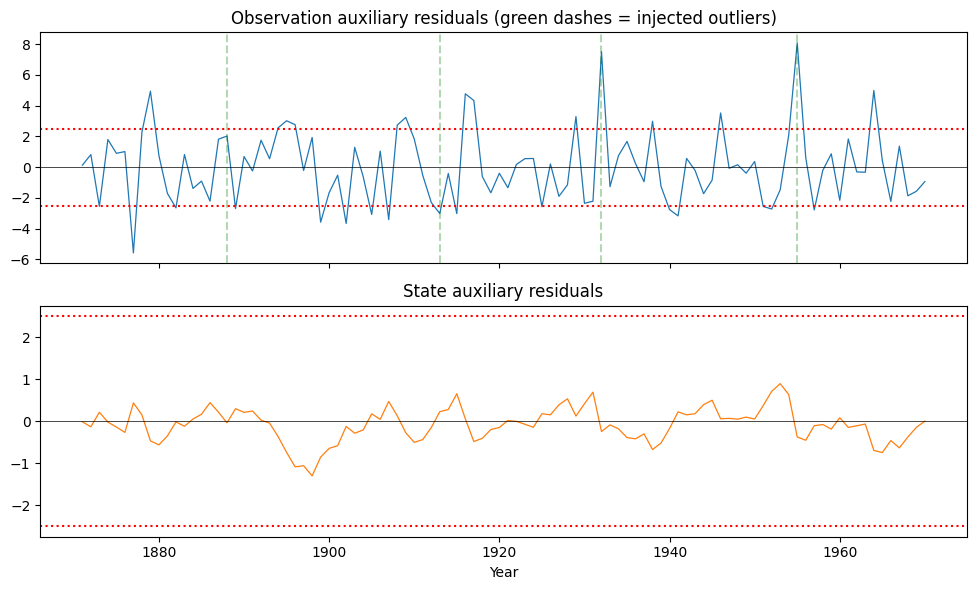

Threshold |e_eps| > 2.5
  true outlier years    : [1888, 1913, 1932, 1955]
  flagged years         : [1873, 1877, 1879, 1882, 1889, 1894, 1895, 1896, 1899, 1902, 1905, 1907, 1908, 1909, 1913, 1915, 1916, 1917, 1925, 1929, 1932, 1938, 1940, 1941, 1946, 1951, 1952, 1955, 1957, 1964]
  true positives (3/4): [1913, 1932, 1955]
  false negatives       : [1888]
  false positives       : [1873, 1877, 1879, 1882, 1889, 1894, 1895, 1896, 1899, 1902, 1905, 1907, 1908, 1909, 1915, 1916, 1917, 1925, 1929, 1938, 1940, 1941, 1946, 1951, 1952, 1957, 1964]


In [13]:
obs_r_out, st_r_out = auxiliary_residuals(fit_out_sm)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(nile_out['year'], obs_r_out, lw=0.9)
axes[0].axhline(2.5, color='red', ls=':')
axes[0].axhline(-2.5, color='red', ls=':')
axes[0].axhline(0, color='black', lw=0.5)
true_years = nile_out.loc[nile_out['is_outlier'], 'year'].tolist()
for y_true in true_years:
    axes[0].axvline(y_true, color='green', alpha=0.3, ls='--')
axes[0].set_title('Observation auxiliary residuals (green dashes = injected outliers)')
axes[1].plot(nile_out['year'], st_r_out, lw=0.9, color='C1')
axes[1].axhline(2.5, color='red', ls=':')
axes[1].axhline(-2.5, color='red', ls=':')
axes[1].axhline(0, color='black', lw=0.5)
axes[1].set_title('State auxiliary residuals')
axes[1].set_xlabel('Year')
plt.tight_layout()
plt.show()

threshold = 2.5
flagged_mask = np.abs(obs_r_out) > threshold
flagged_years = nile_out.loc[flagged_mask, 'year'].tolist()
true_set = set(true_years)
flagged_set = set(flagged_years)
tp = sorted(true_set & flagged_set)
fn = sorted(true_set - flagged_set)
fp = sorted(flagged_set - true_set)
print(f'Threshold |e_eps| > {threshold}')
print(f'  true outlier years    : {true_years}')
print(f'  flagged years         : {flagged_years}')
print(f'  true positives ({len(tp)}/{len(true_set)}): {tp}')
print(f'  false negatives       : {fn}')
print(f'  false positives       : {fp}')

## 9. Conclusions

* On the **clean Nile** series the local-level model produces residuals that pass
  Jarque-Bera, Shapiro-Wilk, Ljung-Box, and Harvey's H test at the 5% level. The
  CUSUM trajectory stays inside the bands. The state auxiliary residual still spikes
  around 1899 because there is a real level shift the model is unable to absorb.
* On the **outlier-augmented** series, the same diagnostics deteriorate and the
  observation auxiliary residual flags the four injected years.
* The practical recipe for diagnostics is:
  1. Plot the 4-panel summary - a structural problem usually shows up visually.
  2. Run the formal tests; if anything fails, do not trust the standard errors.
  3. Inspect auxiliary residuals to *localise* the violation:
     - $|e_{\varepsilon,t}| > 2.5$ -> additive outlier in $y_t$,
     - $|e_{\eta,t}| > 2.5$ -> level shift / structural break.
  4. Re-fit with intervention dummies, robust noise, or a richer model and re-run.